# Using Notebooks

`brainrender` can be used with Jupyter notebooks in two ways:

1. you can **embed** a window with your rendered scene
2. you can have your scene be rendered in a **pop-up** window.


## Rendering your scene in a separate window

If you want your scene to be rendered in a new window, then set this option before you create 
your `Scene`.

```python
import vedo
vedo.settings.default_backend= 'vtk'
```
After this everything will work exactly the same as usual, and you will have access to all of brainrender's features. 


### To visualise primary visual cortex in the Allen Adult Mouse Brain Atlas:

In [1]:
from pathlib import Path
from brainrender._io import load_mesh_from_file
from myterial import orange
from rich import print
from brainglobe_atlasapi import BrainGlobeAtlas
from brainrender import Scene
import brainrender
from brainrender.actors import Points, Line
import numpy as np

bg_atlas = BrainGlobeAtlas("allen_mouse_100um", check_latest=False)
bg_atlas.lookup_df.acronym.values
region = 'TH'
obj_file = str(bg_atlas.meshfile_from_structure(region))


mesh = load_mesh_from_file(obj_file, alpha=0.2, color="green")


In [2]:
from utils import slice_util
slice_util.combine_obj_files([str(bg_atlas.root_dir).replace("\\",'/')+"/meshes"],'output')


C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/1.obj
(458, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/2.obj
(1554, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/4.obj
(4912, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/6.obj
(6966, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/7.obj
(2042, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/8.obj
(175464, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/9.obj
(914, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/10.obj
(4904, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/12.obj
(316, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/15.obj
(754, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/17.obj
(4532, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/19.obj
(848, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/20.obj
(4726, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.


[
    [
        array([[ 7.44774e+03,  6.46268e+03,  4.40832e+03],
       [ 7.40515e+03,  6.48294e+03,  4.41279e+03],
       [ 7.43069e+03,  6.49742e+03,  4.40683e+03],
       ...,
       [-8.66904e-02,  4.92623e-01,  8.65915e-01],
       [ 1.18135e-02, -2.35655e-01,  9.71765e-01],
       [-2.46965e-01, -2.51765e-01,  9.35747e-01]], shape=(458, 3)),
        array([[ 5.57215e+03,  3.41861e+03,  2.36036e+03],
       [ 5.57806e+03,  3.42322e+03,  2.35613e+03],
       [ 5.56766e+03,  3.38563e+03,  2.38106e+03],
       ...,
       [ 2.23618e-02,  1.43289e-01,  9.89428e-01],
       [ 1.53647e-01, -4.84072e-01,  8.61433e-01],
       [-4.77562e-02, -2.17424e-01,  9.74908e-01]], shape=(1554, 3)),
        array([[ 9.59500e+03,  2.97677e+03,  3.51618e+03],
       [ 9.70725e+03,  2.96054e+03,  3.52233e+03],
       [ 9.67638e+03,  2.91110e+03,  3.52722e+03],
       ...,
       [-1.15164e-01,  1.11097e-01,  9.87114e-01],
       [ 3.40808e-02,  2.01248e-01,  9.78947e-01],
       [-3.75239e-02,  2.58

In [4]:
mesh.center_of_mass()

array([7166.51413621, 3954.43378887, 5671.40144396])

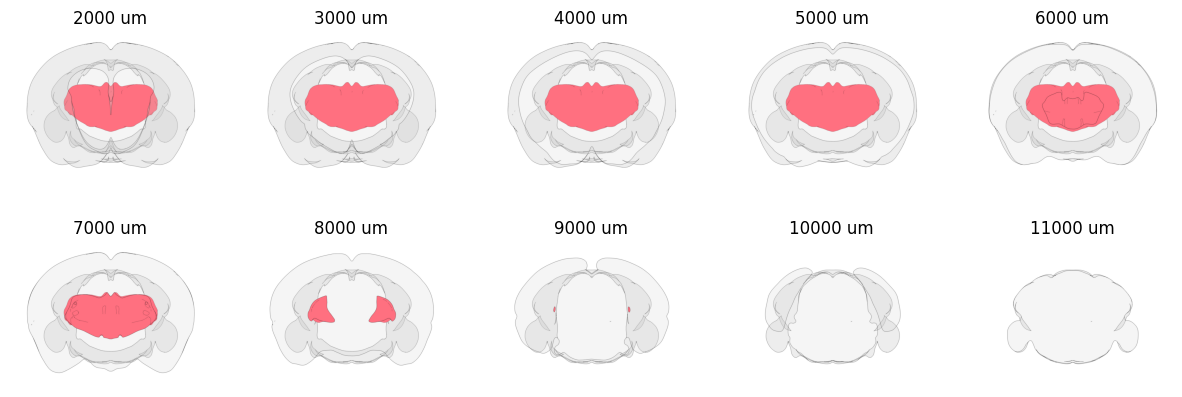

In [1]:
import vedo
vedo.settings.default_backend= 'vtk'

from brainrender import Scene
popup_scene = Scene(atlas_name='allen_mouse_50um', title='popup')

popup_scene.add_brain_region('VISp')

popup_scene.render()  # press 'Esc' to close

Output()

## Embedding the scene

When embedding renderings in Jupyter Notebook not all of `brainrender`'s functionality will work! 
If you want to support all of `brainrender`'s features you should **not embed** renderings in the notebooks.

Note that this is due to the backend (`k3d`) used to embed the renderings, and not because of `brainrender`.

If you still need to embed your `Scene` then `brainrender` works slightly differently.

### To visualise the tectum in the larval zebrafish atlas:

In [2]:
# Set the backend
import vedo
vedo.settings.default_backend= 'k3d'

# Create a brainrender scene
from brainrender import Scene
scene = Scene(atlas_name='mpin_zfish_1um', title='Embedded')  # note the title will not actually display
scene.add_brain_region('tectum')

# Make sure it gets embedded in the window
scene.jupyter = True

# scene.render now will prepare the scene for rendering, but it won't render anything yet
scene.render()

# To display the scene we use `vedo`'s `show` method to show the scene's actors
from vedo import Plotter  # <- this will be used to render an embedded scene 
plt = Plotter()
plt.show(*scene.renderables)  # same as vedo.show(*scene.renderables)

Cannot run function _get_inset in a jupyter notebook Try setting the correct backend before creating your scene:

from vedo import embedWindow                                                                                       
embedWindow(None)                                                                                                  

Your scene is ready for rendering, use:

from vedo import show                                                                                              
vedo.show(*scene.renderables)                                                                                      

c:\workkspace\brainrender_env\Lib\site-packages\traittypes\traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Plot(antialias=True, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], backgro…